## **I. Libraries and Data**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## **II. Data Exploratory**

In [5]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

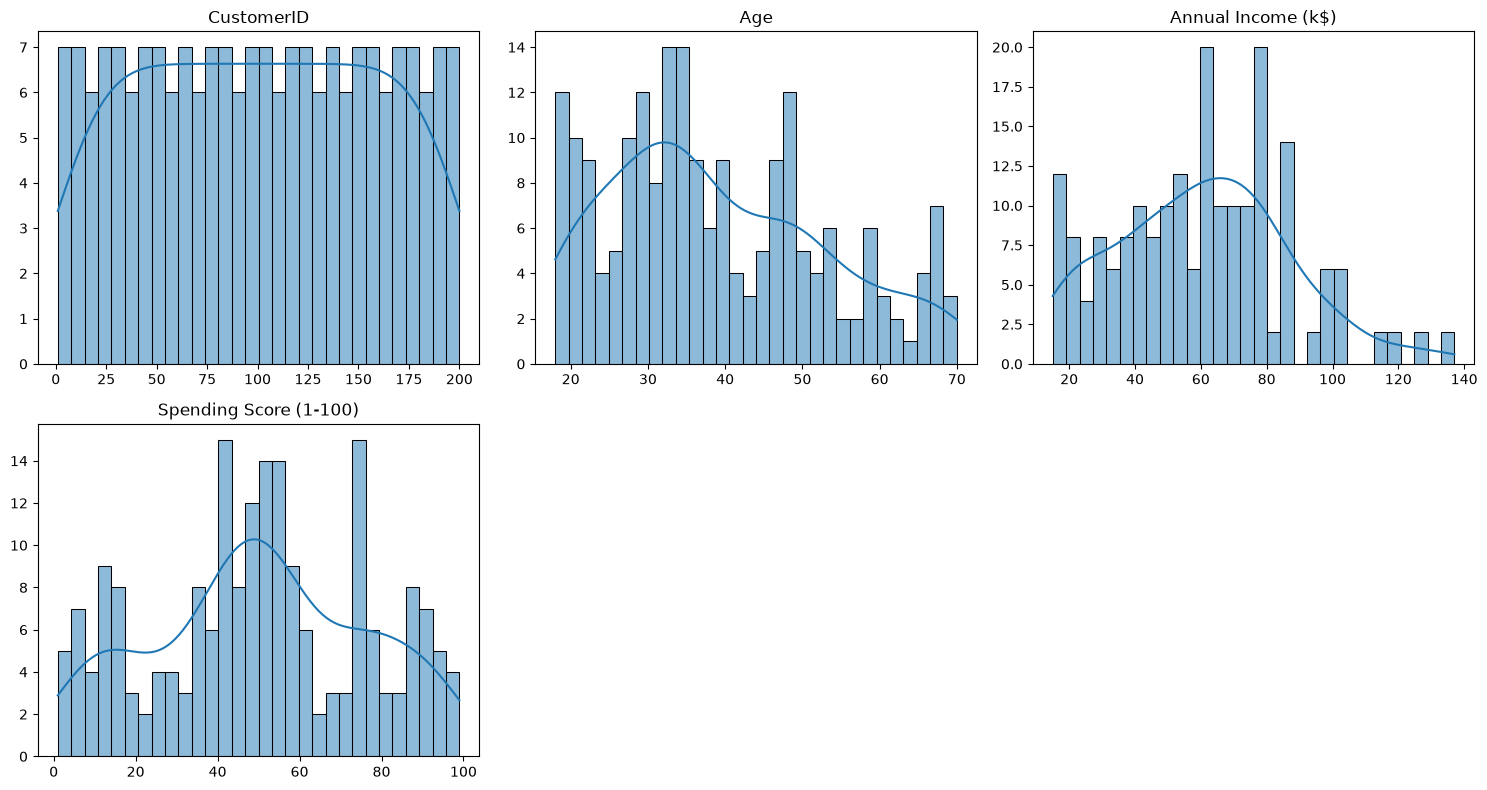

In [6]:
plot_all_histograms(df)

<Axes: xlabel='Genre', ylabel='count'>

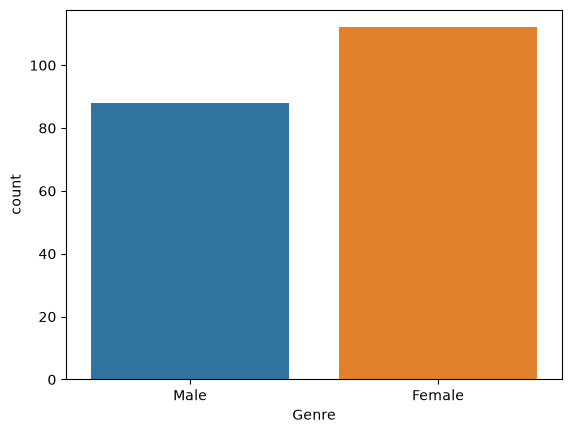

In [7]:
sns.countplot(data=df, x="Genre", hue="Genre")

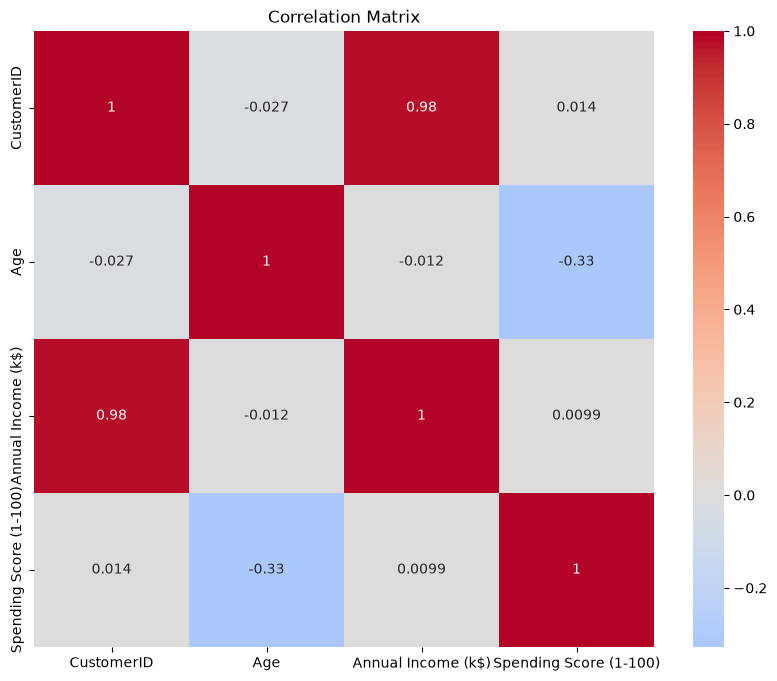

In [8]:
# Correlation matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

## **III. Feature Normalization**

In [9]:
label_encoder = LabelEncoder()
df['Genre'] = label_encoder.fit_transform(df['Genre'])
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
5,6,0,22,17,76
6,7,0,35,18,6
7,8,0,23,18,94
8,9,1,64,19,3
9,10,0,30,19,72


In [12]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df = pd.DataFrame(df_scaled, columns = df.columns)
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0.000000,1.0,0.019231,0.000000,0.387755
1,0.005025,1.0,0.057692,0.000000,0.816327
2,0.010050,0.0,0.038462,0.008197,0.051020
3,0.015075,0.0,0.096154,0.008197,0.775510
4,0.020101,0.0,0.250000,0.016393,0.397959
5,0.025126,0.0,0.076923,0.016393,0.765306
6,0.030151,0.0,0.326923,0.024590,0.051020
7,0.035176,0.0,0.096154,0.024590,0.948980
8,0.040201,1.0,0.884615,0.032787,0.020408
9,0.045226,0.0,0.230769,0.032787,0.724490


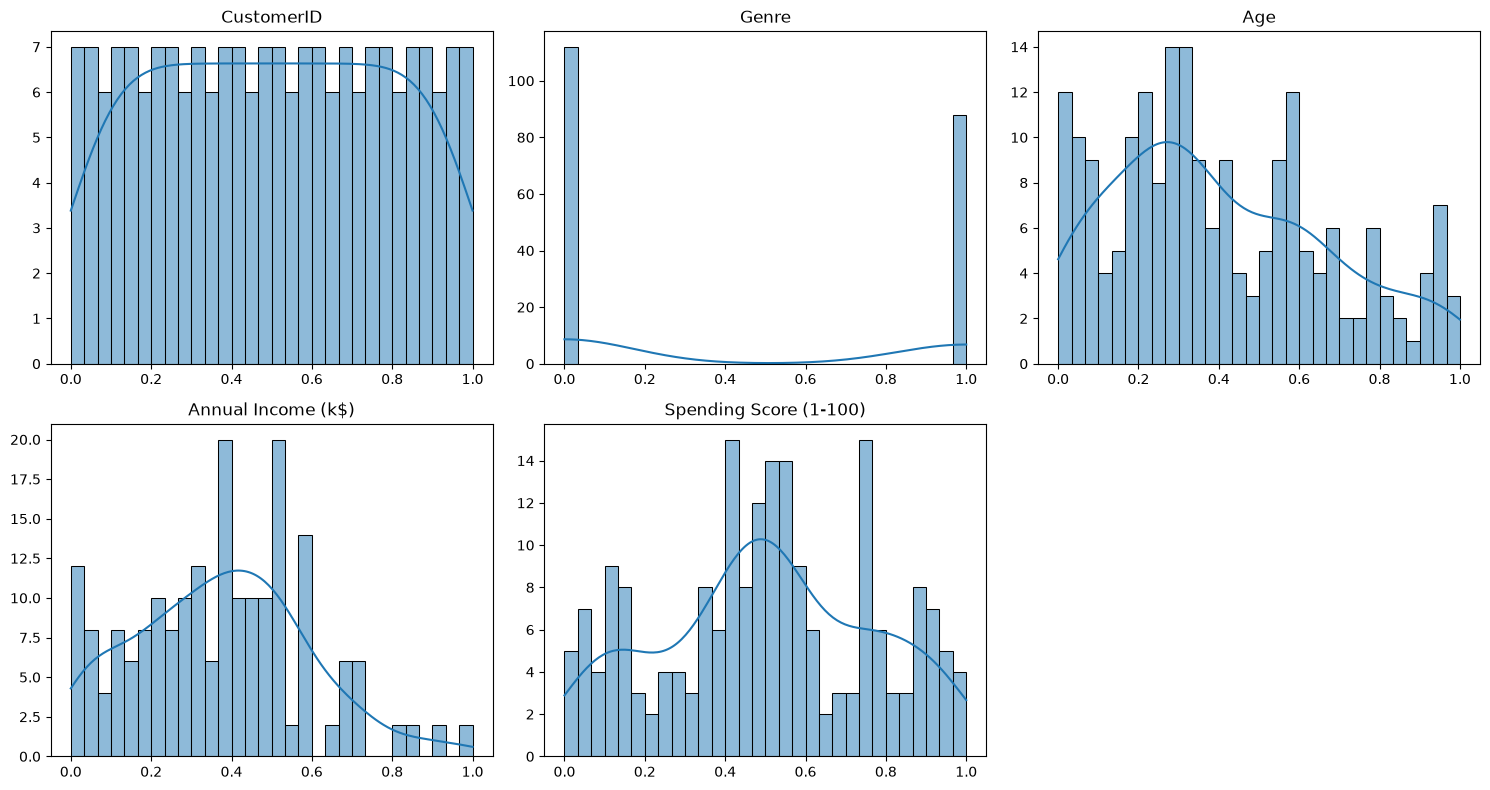

In [13]:
plot_all_histograms(df)

## **IV. K-Means Clustering**

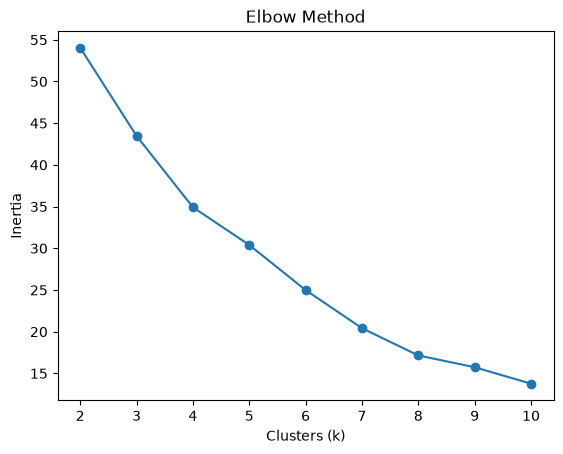

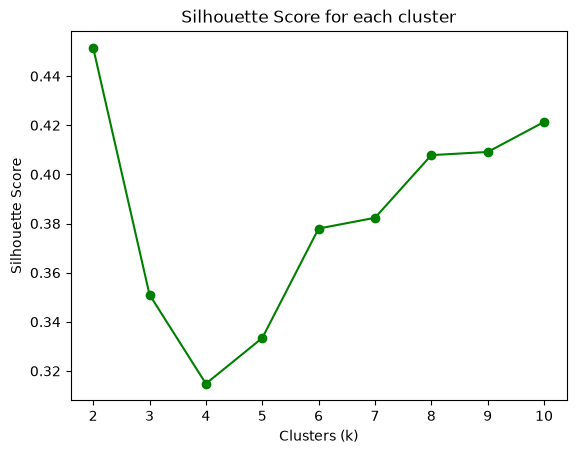

In [15]:
inertia = []
silhouette_scores = []

k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Vẽ Elbow Method
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Vẽ Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.xlabel('Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for each cluster')
plt.show()

In [17]:
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal cluster by Silhouette Score: {optimal_k}")
print(f"Silhouette Score Max: {max(silhouette_scores):.3f}")

Optimal cluster by Silhouette Score: 2
Silhouette Score Max: 0.452


In [18]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

In [19]:
silhouette_score(df_scaled, kmeans.labels_)

0.4213418319730954

In [20]:
silhouette_score(df_scaled, cluster_labels)

0.45157033770569144